# DEF-D Fysieke Ontwerpopdracht 5 Invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 43     |  |
| :-------------|:-------------|
| Mees van Zeeland| 6488021 |
| Floris Dekker| 6325556 |
| Juraj Hadak| 5989779 |

## Opdracht 1: Planning.

| Planning Groep: 43     |Tijdstip / Tijdspanne  | door wie  |
|---|---|---|
| Arduino testen| 10.30-11.30| Juraj |
| ontwerp-eis berekenen| 10.30-11.30 | Mees en Floris|
| grafiek plotten | 11.30-12.30 | hele groep |
| ontwerpen en testen | 13.30-16.30 | hele groep |
| opdruimen en nakijken| 16.30-einde | hele groep |
| eerste ontwerp af |14.30  | ---|
| eerste ontwerp gerealiseerd | 15.30 | ---|
| Pauze 1| 12.30-13.30 | hele groep |


Run onderstaande cel om alle benodigde libraries te laden. Mogelijk voeg je er zelf nog een aantal toe later vandaag. 

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
import math

## Opdracht 2a: Opsplitsen taak 1: Arduino
Vul onderstaande tabel in:

| onderwerp    | antwoord  |
|---|---|
| hoe moeilijk (schaal 1 - 10) | 2 |
| hoe lang voor één meting | 1 min |
| verwacht nauwkeurigheid meting | 0.1 voor frequentie en 0.4 voor amplitude ratio |

## Opdracht 2b: Opsplitsen taak 2: afleiding ontwerpeis

In [2]:
# Bereken hier je benodigde kantelfrequentie
A_m_door_A_v = 1/3
Freq_v = 5
def eigenF(a, x):
    return a/(np.sqrt(np.abs(1+(1/x))))

print(eigenF(5,1/3))

2.5


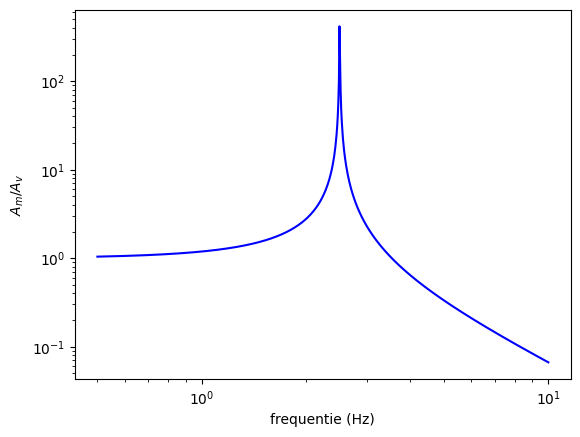

In [3]:
def overdracht(f, f_0):
    return np.abs(1/(1-np.square(f/f_0)))
f_0 = 2.5 # Hz
vfrequenties = np.linspace(0.5,10, 1000)
x = overdracht(vfrequenties, f_0)

plt.plot(vfrequenties, x, "b-")
plt.xlabel("frequentie (Hz)")
plt.ylabel("$A_m/A_v$")
plt.xscale("log")
plt.yscale("log")
plt.show()



In [4]:
# Bereken hier de minimale Delta-x waarbij je aan de eis van de opdracht voldoet.
g = 9.81
omega_0 = 2.5 * 2 * np.pi
delta_x = g/np.square(omega_0)

print(delta_x)

0.039758432461253344


## Opdracht 3: Plot de grafiek.

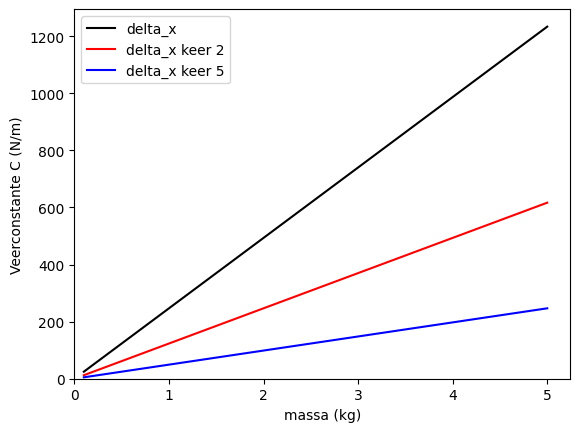

In [5]:
# Voeg hier je plot in. Lees goed de opdracht wat er in de grafiek moet staan!
def c(m, g, delta_x):
    return (m*g)/delta_x
massa = np.linspace(0.1, 5, 50)
delta_x2 = 2* delta_x
delta_x5 = 5* delta_x

plt.plot(massa, c(massa, g, delta_x), "k-", label = "delta_x")
plt.plot(massa, c(massa, g, delta_x2), "r-", label = "delta_x keer 2")
plt.plot(massa, c(massa, g, delta_x5), "b-", label = "delta_x keer 5")
plt.xlabel("massa (kg)")
plt.ylabel("Veerconstante C (N/m)")
plt.xlim(0,)
plt.ylim(0,)
plt.legend()
plt.show()

# Het is ook handig om je grafiek op te slaan, doe dat door met plt.savefig().

## Opdracht 4: Verander $\Delta x$.

We kunnen $\Delta x$ verhogen door:

- Een grotere massa te nemen
- Een lagere veerconstante te nemen

Vul onderstaande aan. Geef eventueel met tekst aan waarom je hiervoor gekozen hebt, als extra informatie richting de nakijkers. 

Als groep gaan we mikken op een $\Delta x$ van: 10 cm omdat je dan een demping van meer dan een derde krijgt

## Opdracht 5: Schets.

##### schets opstelling: 
<img src="Schets2.jpeg" width="400">

## Opdracht 6: Beslissing evaluatie

Voldoet je ontwerp aan de eisen? Beantwoord de volgende vragen:

### Wat is de $\Delta x$ van je ontwerp?

10 cm

### Wordt die $\Delta x$ behaald met je gekozen massa en veer?

ja net iets meer (15 cm)

### hoeveel verder kan je massa-veer systeem nog uitrekken / indrukken?
Wat is de limiet aan je veer / verend materiaal voordat het niet meer lineair reageert volgens de wet van Hooke?

4 cm is de rustlengte, hij kan tot 60 centimeter oprekken totdat hij vervormd

### Is dat genoeg om straks metingen te kunnen doen?
Hou er rekening mee dat je trillingen een amplitude in de orde grote van een paar centimeter gaan hebben, minder is met deze opzet moeilijk te realiseren.

ja

### Gaat je ontwerp dus voldoen aan de eis?

ja

Als je hier positief geantwoord heb, maak dan nog een keer een plot van amplitude overdracht (y-as) versus frequentie (x-as) zoals je hierboven ook al een keer gedaan heb, maar plot nu twee verschillende overdrachten in de grafiek: één die je al had: behorende bij de grens van de ontwerp-eis en één behorende bij je eigen ontwerp. Lees af dat je voor je ontwerp daadwerkelijk onder de eis grafiek zit op de kritieke frequentie!

Deze grafiek heb je later weer nodig om je gemeten punten aan toe te voegen. Ga daarna je massa-veer systeem daadwerkelijk bouwen.

Als je hier negatief geantwoord hebt, kopieer onder deze cel dan alle cellen van Synthese tot en met Evaluation & decision en doorloop dat deel van het ontwerp proces nogmaals.

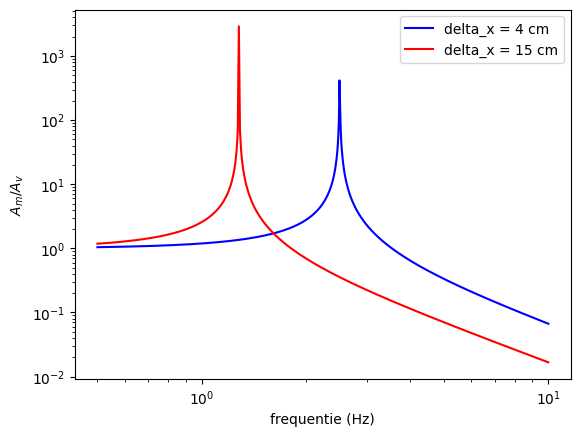

In [6]:
def overdracht(f, f_0):
    return np.abs(1/(1-np.square(f/f_0)))
f_0_1 = 2.5 # Hz bij delta x 4 cm
vfrequenties = np.linspace(0.5,10, 1000)
f_0_2 = 1.28 # Hz voor onze eigen opstelling bij delta_x van 15 cm

plt.plot(vfrequenties, overdracht(vfrequenties, f_0), "b-", label = "delta_x = 4 cm")
plt.plot(vfrequenties, overdracht(vfrequenties,f_0_2 ), "r-", label = "delta_x = 15 cm")
plt.legend()
plt.xlabel("frequentie (Hz)")
plt.ylabel("$A_m/A_v$")
plt.xscale("log")
plt.yscale("log")
plt.show()





## Opdracht 7: Plotten maar

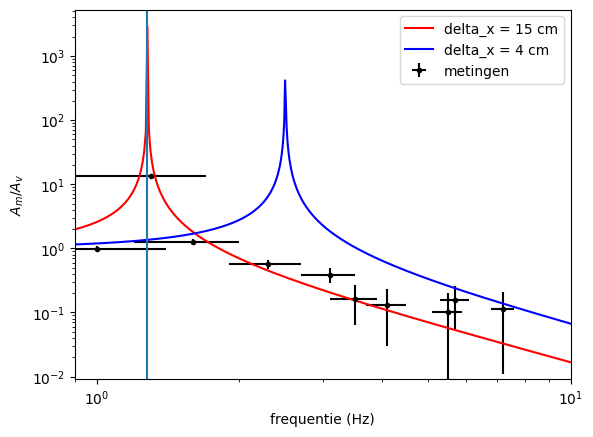

In [7]:
Freq = np.array([1.6, 2.3, 4.1, 5.7, 7.2, 3.1, 3.5, 5.5,1, 1.3])
A_m = np.array([0.23, 0.37, 0.24, 0.97, 0.10, 0.41, 0.28, 0.63,0.73, 10])
A_v = np.array([0.18, 0.65, 1.85, 6.23, 0.90, 1.05, 1.71, 6.30,0.74, 0.75])
demping = A_m/A_v


plt.errorbar(Freq, demping,0.1, 0.4, "k.", label = "metingen")
plt.plot(vfrequenties, overdracht(vfrequenties,f_0_2 ), "r-", label = "delta_x = 15 cm")
plt.plot(vfrequenties, overdracht(vfrequenties, f_0), "b-", label = "delta_x = 4 cm")
plt.xlabel("frequentie (Hz)")
plt.ylabel("$A_m/A_v$")
plt.xscale("log")
plt.yscale("log")
plt.axvline(1.28)
plt.xlim(0.90,1e1)
plt.legend()
plt.show()

## Opdracht 8: Leerdoelen
Voeg hieronder zelf kopjes toe om aan te geven wat bij welk leerdoel hoort. 

Inzien dat parameters ...

In [8]:
# Bereken hier je benodigde kantelfrequentie
A_m_door_A_v = 1/3
Freq_v = 5
def eigenF(a, x):
    return a/(np.sqrt(np.abs(1+(1/x))))

print(eigenF(5,1/3))

2.5


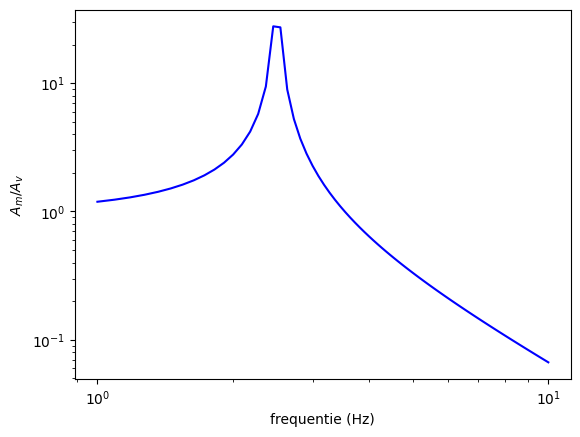

In [9]:
def overdracht(f, f_0):
    return np.abs(1/(1-np.square(f/f_0)))
f_0 = 2.5 # Hz
vfrequenties = np.linspace(1,10, 100)
x = overdracht(vfrequenties, f_0)

plt.plot(vfrequenties, x, "b-")
plt.xlabel("frequentie (Hz)")
plt.ylabel("$A_m/A_v$")
plt.xscale("log")
plt.yscale("log")
plt.show()



In [10]:
# Bereken hier de minimale Delta-x waarbij je aan de eis van de opdracht voldoet.
g = 9.81
omega_0 = 2.5 * 2 * np.pi
delta_x = g/np.square(omega_0)

print(delta_x, " is ongeveer 4 cm")

0.039758432461253344  is ongeveer 4 cm


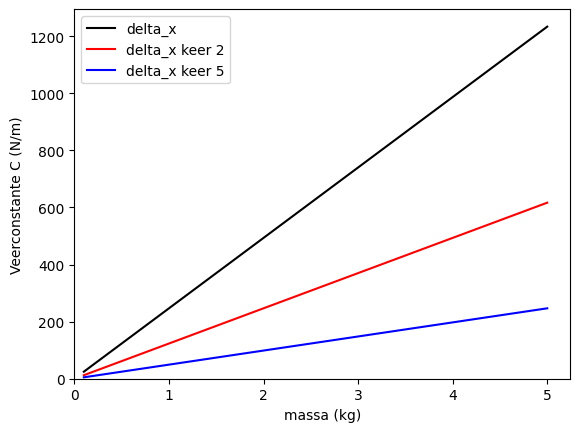

In [11]:
# Voeg hier je plot in. Lees goed de opdracht wat er in de grafiek moet staan!
def c(m, g, delta_x):
    return (m*g)/delta_x
massa = np.linspace(0.1, 5, 50)
delta_x2 = 2* delta_x
delta_x5 = 5* delta_x

plt.plot(massa, c(massa, g, delta_x), "k-", label = "delta_x")
plt.plot(massa, c(massa, g, delta_x2), "r-", label = "delta_x keer 2")
plt.plot(massa, c(massa, g, delta_x5), "b-", label = "delta_x keer 5")
plt.xlabel("massa (kg)")
plt.ylabel("Veerconstante C (N/m)")
plt.xlim(0,)
plt.ylim(0,)
plt.legend()
plt.show()

# Het is ook handig om je grafiek op te slaan, doe dat door met plt.savefig().

Op basis van een differentiaalvergelijking ...

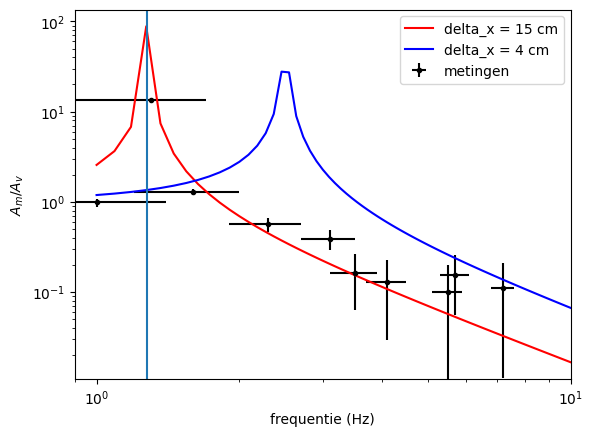

In [12]:
Freq = np.array([1.6, 2.3, 4.1, 5.7, 7.2, 3.1, 3.5, 5.5,1, 1.3])
A_m = np.array([0.23, 0.37, 0.24, 0.97, 0.10, 0.41, 0.28, 0.63,0.73, 10])
A_v = np.array([0.18, 0.65, 1.85, 6.23, 0.90, 1.05, 1.71, 6.30,0.74, 0.75])
demping = A_m/A_v


plt.errorbar(Freq, demping,0.1, 0.4, "k.", label = "metingen")
plt.plot(vfrequenties, overdracht(vfrequenties,f_0_2 ), "r-", label = "delta_x = 15 cm")
plt.plot(vfrequenties, overdracht(vfrequenties, f_0), "b-", label = "delta_x = 4 cm")
plt.xlabel("frequentie (Hz)")
plt.ylabel("$A_m/A_v$")
plt.xscale("log")
plt.yscale("log")
plt.axvline(1.28)
plt.xlim(0.90,1e1)
plt.legend()
plt.show()

##### schets opstelling: 
<img src="Schets2.jpeg" width="400">

Voldoet je ontwerp aan de eisen? Beantwoord de volgende vragen:

### Wat is de $\Delta x$ van je ontwerp?

10 cm

### Wordt die $\Delta x$ behaald met je gekozen massa en veer?

ja net iets meer (15 cm)

### hoeveel verder kan je massa-veer systeem nog uitrekken / indrukken?
Wat is de limiet aan je veer / verend materiaal voordat het niet meer lineair reageert volgens de wet van Hooke?

4 cm is de rustlengte, hij kan tot 60 centimeter oprekken totdat hij vervormd

### Is dat genoeg om straks metingen te kunnen doen?
Hou er rekening mee dat je trillingen een amplitude in de orde grote van een paar centimeter gaan hebben, minder is met deze opzet moeilijk te realiseren.

ja

### Gaat je ontwerp dus voldoen aan de eis?

ja

Als je hier positief geantwoord heb, maak dan nog een keer een plot van amplitude overdracht (y-as) versus frequentie (x-as) zoals je hierboven ook al een keer gedaan heb, maar plot nu twee verschillende overdrachten in de grafiek: één die je al had: behorende bij de grens van de ontwerp-eis en één behorende bij je eigen ontwerp. Lees af dat je voor je ontwerp daadwerkelijk onder de eis grafiek zit op de kritieke frequentie!

Deze grafiek heb je later weer nodig om je gemeten punten aan toe te voegen. Ga daarna je massa-veer systeem daadwerkelijk bouwen.

Als je hier negatief geantwoord hebt, kopieer onder deze cel dan alle cellen van Synthese tot en met Evaluation & decision en doorloop dat deel van het ontwerp proces nogmaals.

We kunnen $\Delta x$ verhogen door:

- Een grotere massa te nemen
- Een lagere veerconstante te nemen

Vul onderstaande aan. Geef eventueel met tekst aan waarom je hiervoor gekozen hebt, als extra informatie richting de nakijkers. 

Als groep gaan we mikken op een $\Delta x$ van: 10 cm omdat je dan een demping van meer dan een derde krijgt